In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_with_selected_features_and_all_outliers = pd.read_csv("../data/data_cleaned_selected_with_all_outliers.csv", index_col=0)
df_with_selected_features_and_no_outliers = pd.read_csv("../data/data_cleaned_selected_with_no_outliers.csv", index_col=0)
df_with_all_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_with_no_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_no_outliers_and_all_features.csv", index_col=0)
print("Data Shape of df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.shape)
print("Data Shape of df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.shape)
print("Data Shape of df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.shape)
print("Data Shape of df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.shape)

Data Shape of df_with_selected_features_and_all_outliers:  (4424, 6)
Data Shape of df_with_selected_features_and_no_outliers:  (4335, 6)
Data Shape of df_with_all_outliers_and_all_features:  (4424, 35)
Data Shape of df_with_no_outliers_and_all_features:  (4335, 35)


In [3]:
print("Columns in df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.columns)
print("Columns in df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.columns)

Columns in df_with_selected_features_and_all_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')
Columns in df_with_selected_features_and_no_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')


In [4]:
print("Columns in df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.columns)
print("Columns in df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.columns)

Columns in df_with_all_outliers_and_all_features:  Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
   

In [5]:
X_a_o_a_f = df_with_all_outliers_and_all_features.drop("Target", axis=1)
y_a_o_a_f = df_with_all_outliers_and_all_features["Target"]
X_a_o_s_f = df_with_selected_features_and_all_outliers.drop("Target", axis=1)
y_a_o_s_f = df_with_selected_features_and_all_outliers["Target"]
X_n_o_a_f = df_with_no_outliers_and_all_features.drop("Target", axis=1)
y_n_o_a_f = df_with_no_outliers_and_all_features["Target"]
X_n_o_s_f = df_with_selected_features_and_no_outliers.drop("Target", axis=1)
y_n_o_s_f = df_with_selected_features_and_no_outliers["Target"]

X_train_a_o_a_f, X_test_a_o_a_f, y_train_a_o_a_f, y_test_a_o_a_f = train_test_split(
    X_a_o_a_f, y_a_o_a_f, test_size=0.2, random_state=42, stratify=y_a_o_a_f
)
X_train_a_o_s_f, X_test_a_o_s_f, y_train_a_o_s_f, y_test_a_o_s_f = train_test_split(
    X_a_o_s_f, y_a_o_s_f, test_size=0.2, random_state=42, stratify=y_a_o_s_f
)
X_train_n_o_a_f, X_test_n_o_a_f, y_train_n_o_a_f, y_test_n_o_a_f = train_test_split(
    X_n_o_a_f, y_n_o_a_f, test_size=0.2, random_state=42, stratify=y_n_o_a_f
)
X_train_n_o_s_f, X_test_n_o_s_f, y_train_n_o_s_f, y_test_n_o_s_f = train_test_split(
    X_n_o_s_f, y_n_o_s_f, test_size=0.2, random_state=42, stratify=y_n_o_s_f
)

# **Random Forest Classifier without Hyperparameter Tuning**

In [6]:
rf_a_o_a_f = RandomForestClassifier(random_state=42)
rf_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)
rf_a_o_s_f = RandomForestClassifier(random_state=42)
rf_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)
rf_n_o_a_f = RandomForestClassifier(random_state=42)
rf_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)
rf_n_o_s_f = RandomForestClassifier(random_state=42)
rf_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

rf_a_o_a_f_pred = rf_a_o_a_f.predict(X_test_a_o_a_f)
rf_a_o_s_f_pred = rf_a_o_s_f.predict(X_test_a_o_s_f)
rf_n_o_a_f_pred = rf_n_o_a_f.predict(X_test_n_o_a_f)
rf_n_o_s_f_pred = rf_n_o_s_f.predict(X_test_n_o_s_f)

# Classification Report
print("Classification Report - Random Forest Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, rf_a_o_a_f_pred))
print("Classification Report - Random Forest Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, rf_a_o_s_f_pred))

Classification Report - Random Forest Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       284
           1       0.58      0.38      0.46       159
           2       0.80      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.77      0.78      0.76       885

Classification Report - Random Forest Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       284
           1       0.40      0.38      0.39       159
           2       0.78      0.84      0.81       442

    accuracy                           0.71       885
   macro avg       0.65      0.64      0.64       885
weighted avg       0.71      0.71      0.71       885



In [7]:
print("Classification Report - Random Forest Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, rf_n_o_a_f_pred))
print("Classification Report - Random Forest Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, rf_n_o_s_f_pred))

Classification Report - Random Forest Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       279
           1       0.51      0.32      0.39       155
           2       0.78      0.91      0.84       433

    accuracy                           0.76       867
   macro avg       0.70      0.67      0.67       867
weighted avg       0.74      0.76      0.75       867

Classification Report - Random Forest Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       279
           1       0.40      0.30      0.34       155
           2       0.75      0.86      0.80       433

    accuracy                           0.71       867
   macro avg       0.64      0.62      0.63       867
weighted avg       0.69      0.71      0.70       867



Confusion Matrix - Random Forest Classifier with All Outliers and All Features:


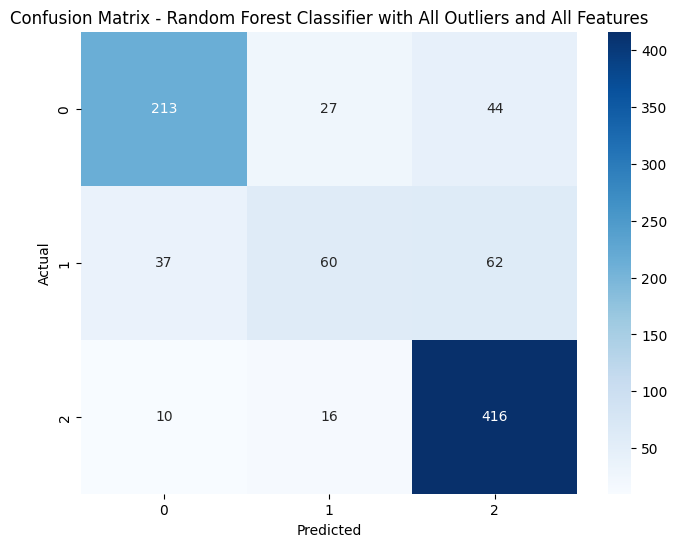

Confusion Matrix - Random Forest Classifier with All Outliers and Selected Features:


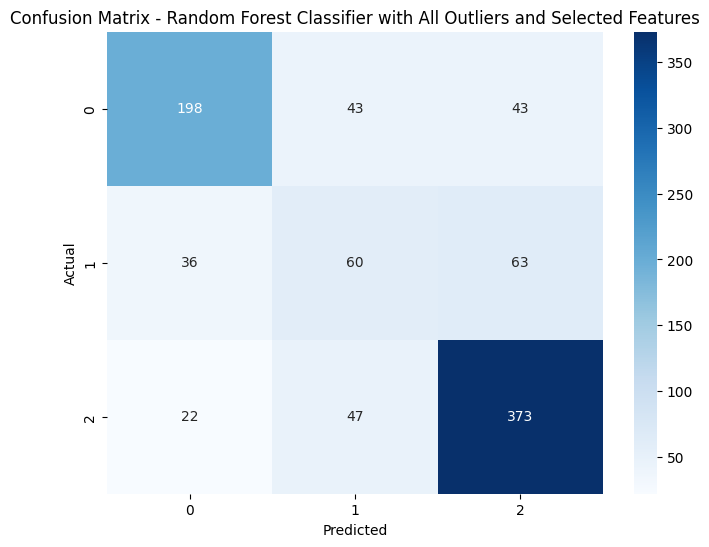

Confusion Matrix - Random Forest Classifier with No Outliers and All Features:


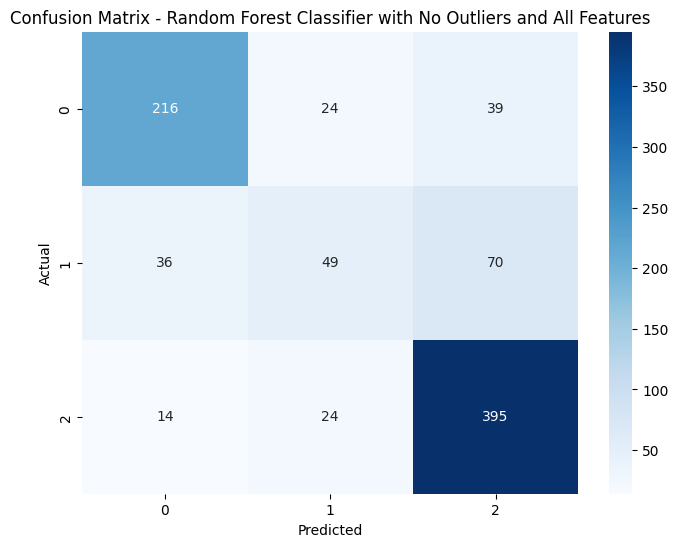

Confusion Matrix - Random Forest Classifier with No Outliers and Selected Features:


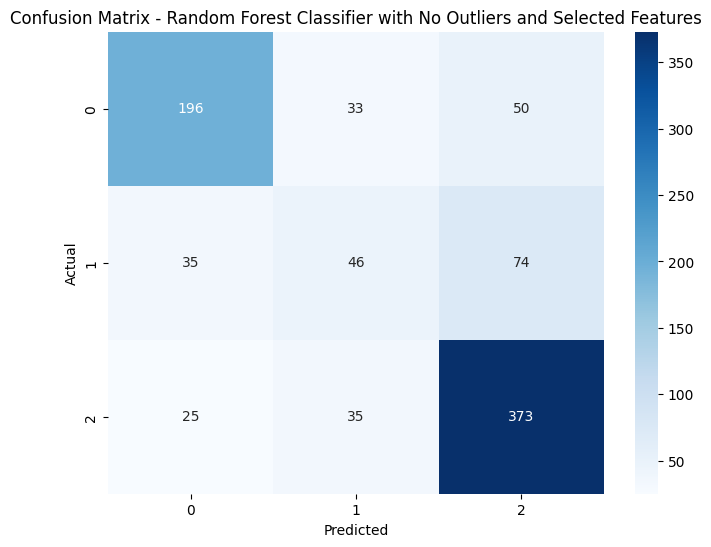

In [8]:
# Plot Confusion Matrix Chart
print("Confusion Matrix - Random Forest Classifier with All Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, rf_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Random Forest Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, rf_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Random Forest Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, rf_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Random Forest Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, rf_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# Accuracy Score
print("Accuracy Score - Random Forest Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, rf_a_o_a_f_pred))
print("Accuracy Score - Random Forest Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, rf_a_o_s_f_pred))
print("Accuracy Score - Random Forest Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, rf_n_o_a_f_pred))
print("Accuracy Score - Random Forest Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, rf_n_o_s_f_pred))

Accuracy Score - Random Forest Classifier with All Outliers and All Features: 0.7785310734463277
Accuracy Score - Random Forest Classifier with All Outliers and Selected Features: 0.7129943502824859
Accuracy Score - Random Forest Classifier with No Outliers and All Features: 0.7612456747404844
Accuracy Score - Random Forest Classifier with No Outliers and Selected Features: 0.7093425605536332


In [10]:
# ROC AUC Score
print("ROC AUC Score - Random Forest Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, rf_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Random Forest Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, rf_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Random Forest Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, rf_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Random Forest Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, rf_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))

ROC AUC Score - Random Forest Classifier with All Outliers and All Features:

 0.8917698487603106
ROC AUC Score - Random Forest Classifier with All Outliers and Selected Features: 0.8347549790186187
ROC AUC Score - Random Forest Classifier with No Outliers and All Features: 0.866555154363663
ROC AUC Score - Random Forest Classifier with No Outliers and Selected Features: 0.8175593049664478


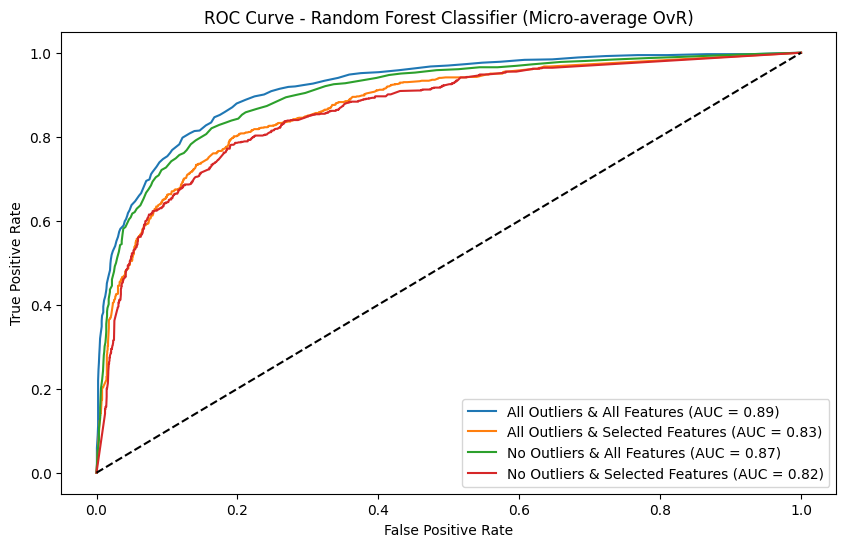

In [11]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, rf_a_o_a_f.predict_proba(X_test_a_o_a_f), rf_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, rf_a_o_s_f.predict_proba(X_test_a_o_s_f), rf_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, rf_n_o_a_f.predict_proba(X_test_n_o_a_f), rf_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, rf_n_o_s_f.predict_proba(X_test_n_o_s_f), rf_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

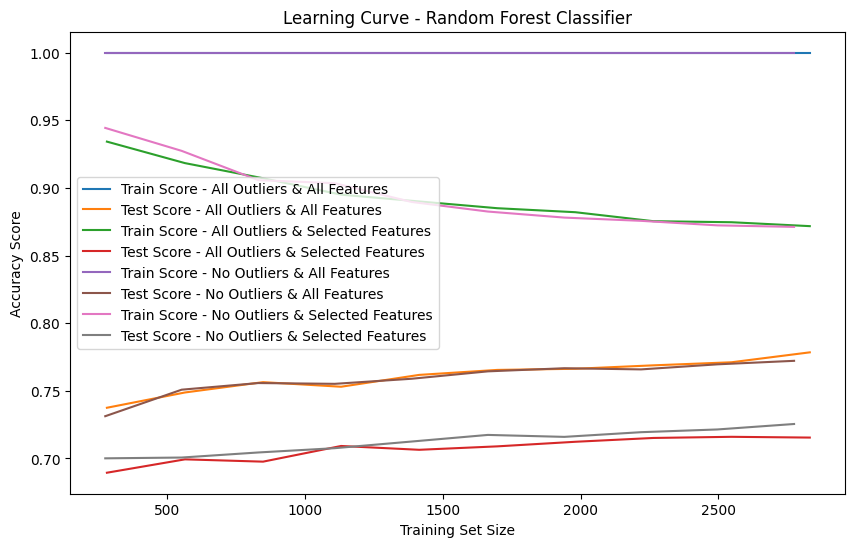

In [12]:
# Learning Curve
train_sizes_a_o_a_f, train_scores_a_o_a_f, test_scores_a_o_a_f = learning_curve(
    rf_a_o_a_f, X_train_a_o_a_f, y_train_a_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_a_o_s_f, train_scores_a_o_s_f, test_scores_a_o_s_f = learning_curve(
    rf_a_o_s_f, X_train_a_o_s_f, y_train_a_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_a_f, train_scores_n_o_a_f, test_scores_n_o_a_f = learning_curve(
    rf_n_o_a_f, X_train_n_o_a_f, y_train_n_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_s_f, train_scores_n_o_s_f, test_scores_n_o_s_f = learning_curve(
    rf_n_o_s_f, X_train_n_o_s_f, y_train_n_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_a_o_a_f, np.mean(train_scores_a_o_a_f, axis=1), label='Train Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_a_f, np.mean(test_scores_a_o_a_f, axis=1), label='Test Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_s_f, np.mean(train_scores_a_o_s_f, axis=1), label='Train Score - All Outliers & Selected Features')
plt.plot(train_sizes_a_o_s_f, np.mean(test_scores_a_o_s_f, axis=1), label='Test Score - All Outliers & Selected Features')
plt.plot(train_sizes_n_o_a_f, np.mean(train_scores_n_o_a_f, axis=1), label='Train Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_a_f, np.mean(test_scores_n_o_a_f, axis=1), label='Test Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_s_f, np.mean(train_scores_n_o_s_f, axis=1), label='Train Score - No Outliers & Selected Features')
plt.plot(train_sizes_n_o_s_f, np.mean(test_scores_n_o_s_f, axis=1), label='Test Score - No Outliers & Selected Features')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve - Random Forest Classifier')
plt.legend(loc='best')
plt.show()

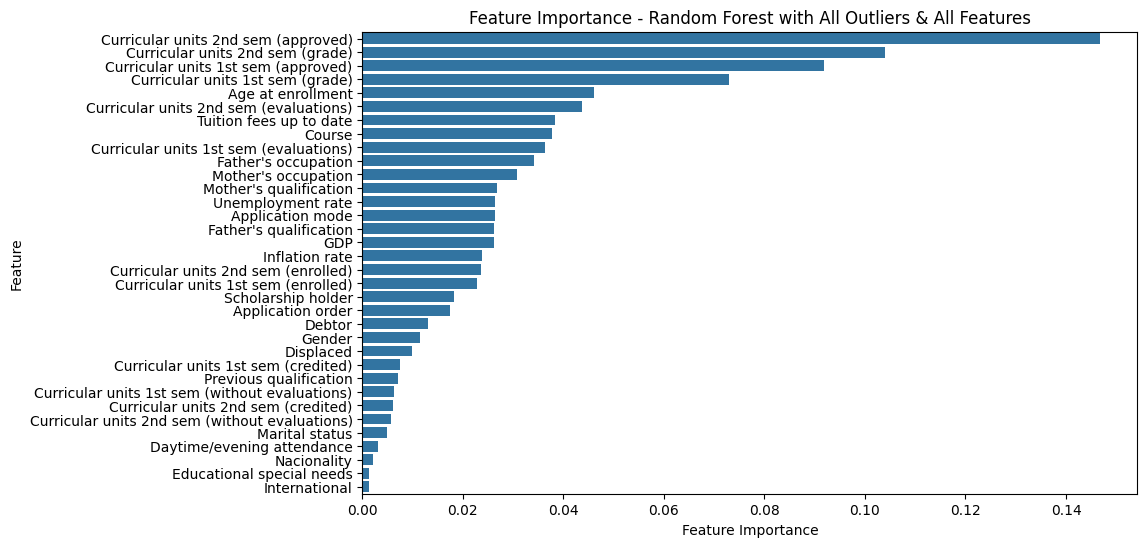

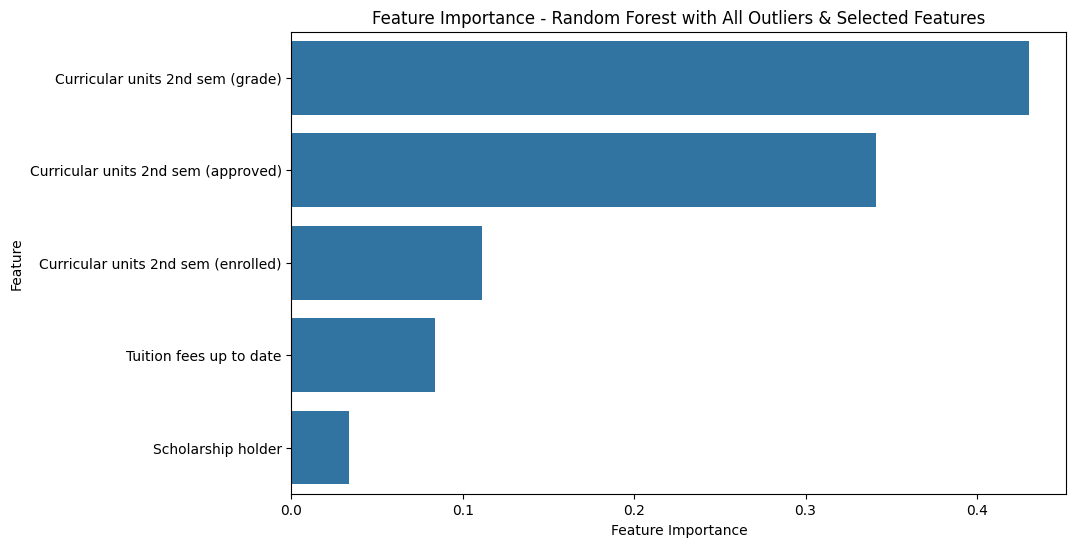

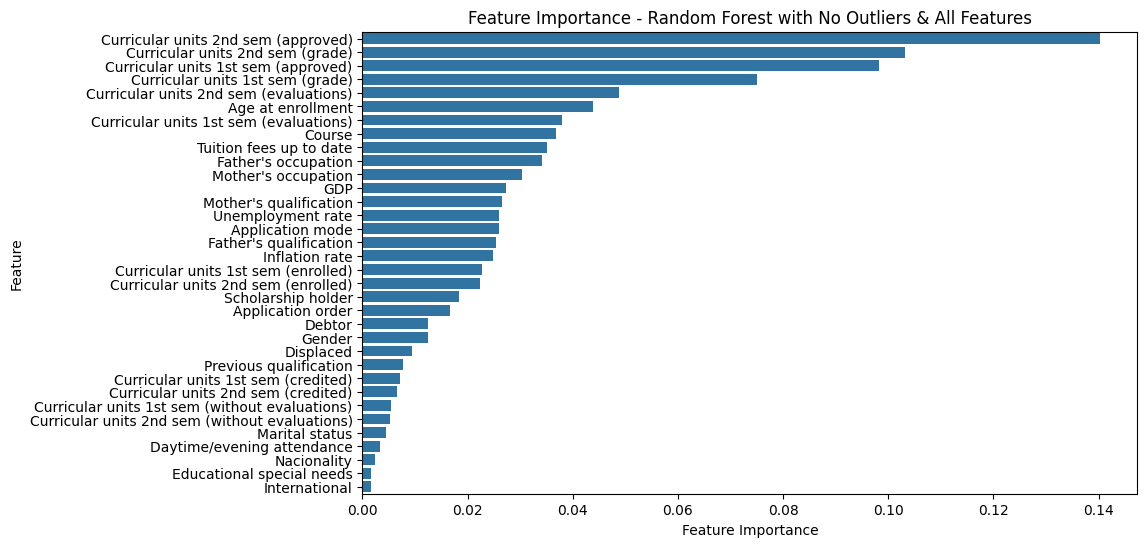

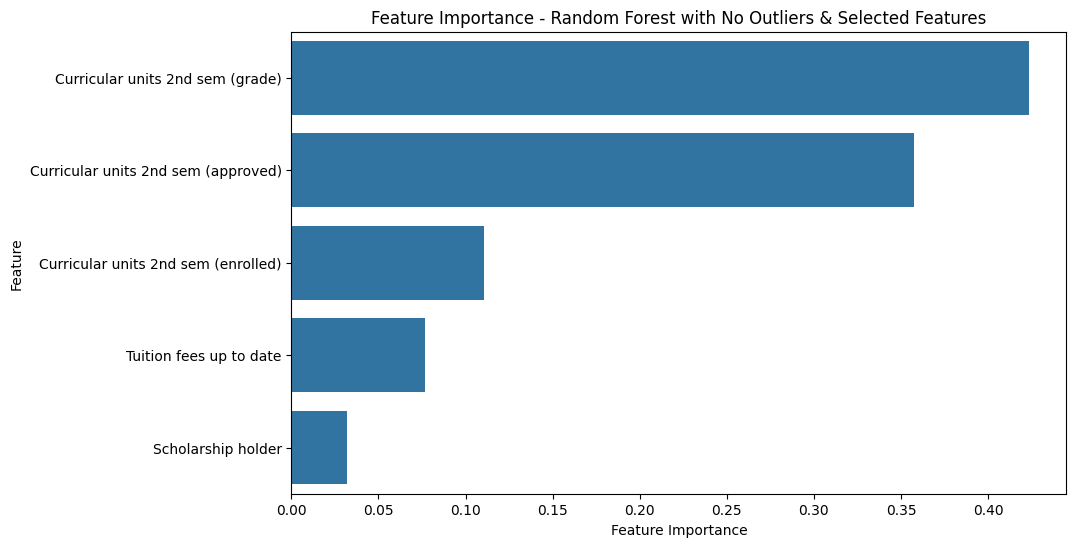

In [13]:
def plot_feature_importance(model, feature_names, title):
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance[indices], y=np.array(feature_names)[indices])
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.show()
plot_feature_importance(rf_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - Random Forest with All Outliers & All Features")
plot_feature_importance(rf_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - Random Forest with All Outliers & Selected Features")
plot_feature_importance(rf_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - Random Forest with No Outliers & All Features")
plot_feature_importance(rf_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - Random Forest with No Outliers & Selected Features")

## **Model Evaluation Summary (Updated from Latest Rerun)**

The best tuned configuration in this notebook is:
**Random Forest with All Outliers and All Features**

### Key Metrics (Tuned Models)
- **Accuracy**: 0.7763 (best)
- **ROC-AUC**: 0.8876 (best)
- **5-Fold CV (AOAF)**: mean 0.7751, std 0.0088

### Interpretation
- Using all features gives stronger performance than selected-feature variants in this Random Forest run.
- Outlier-retained data (All Outliers) gives the best final result for Random Forest after tuning.
- Training-vs-testing gap still indicates overfitting tendency, but tuned AOAF remains the strongest option in this notebook.

### Conclusion
Deploy candidate from this notebook: **Tuned Random Forest (All Outliers + All Features)**.

# **Random Forest with Hyperparameter Tuning**

## **Coarse-to-Fine Search**

### **RandomSearchCV**

In [ ]:
# param_dist = {
#     'n_estimators': np.arange(100, 1001, 100),
#     'max_depth': [None] + list(np.arange(5, 51, 5)),
#     'min_samples_split': np.arange(2, 21),
#     'min_samples_leaf': np.arange(1, 11),
#     'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
#     'bootstrap': [True, False],
#     'max_samples': [None, 0.6, 0.8, 1.0]
# }
# random_search_rf1 = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_rf1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Hyperparameters for Random Forest Classifier with All Outliers and Selected Features (Randomized Search):")
# print(random_search_rf1.best_params_)
# random_search_rf2 = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_rf2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Hyperparameters for Random Forest Classifier with No Outliers and Selected Features (Randomized Search):")
# print(random_search_rf2.best_params_)
# random_search_rf3 = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_rf3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Hyperparameters for Random Forest Classifier with All Outliers and All Features (Randomized Search):")
# print(random_search_rf3.best_params_)
# random_search_rf4 = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_rf4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Hyperparameters for Random Forest Classifier with No Outliers and All Features (Randomized Search):")
# print(random_search_rf4.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for Random Forest Classifier with All Outliers and Selected Features (Randomized Search):
{'n_estimators': np.int64(100), 'min_samples_split': np.int64(5), 'min_samples_leaf': np.int64(2), 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': np.int64(5), 'bootstrap': True}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for Random Forest Classifier with No Outliers and Selected Features (Randomized Search):
{'n_estimators': np.int64(1000), 'min_samples_split': np.int64(14), 'min_samples_leaf': np.int64(9), 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': np.int64(45), 'bootstrap': True}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for Random Forest Classifier with All Outliers and All Features (Randomized Search):
{'n_estimators': np.int64(800), 'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(3), 'max_samp

The duration of RandomSearchCV Task is 5+ Minutes

### **GridSearchCV**

In [ ]:
# param_grid_1 = {
#     'n_estimators': [50, 100, 150],           # sekitar 100
#     'max_depth': [3, 5, 7],                   # sekitar 5
#     'min_samples_split': [3, 5, 7],           # sekitar 5
#     'min_samples_leaf': [1, 2, 3],            # sekitar 2
#     'max_features': [0.3, 0.5, 0.7],          # sekitar 0.5
#     'max_samples': [0.7, 0.8, 0.9],           # sekitar 0.8
#     'bootstrap': [True]                        # sudah pasti True
# }

# grid_1 = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid_1, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Params S1:", grid_1.best_params_)
# print("Best Score S1 :", grid_1.best_score_)

# param_grid_2 = {
#     'n_estimators': [800, 1000, 1200],        # sekitar 1000
#     'max_depth': [35, 45, 55],                # sekitar 45
#     'min_samples_split': [10, 14, 18],        # sekitar 14
#     'min_samples_leaf': [7, 9, 11],           # sekitar 9
#     'max_features': ['sqrt'],                  # sudah pasti sqrt
#     'max_samples': [0.7, 0.8, 0.9],           # sekitar 0.8
#     'bootstrap': [True]                        # sudah pasti True
# }

# grid_2 = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid_2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Params S2:", grid_2.best_params_)
# print("Best Score S2 :", grid_2.best_score_)

# param_grid_3 = {
#     'n_estimators': [600, 800, 1000],         # sekitar 800
#     'max_depth': [20, 25, 30],                # sekitar 25
#     'min_samples_split': [2, 3, 4],           # sekitar 2
#     'min_samples_leaf': [2, 3, 4],            # sekitar 3
#     'max_features': [0.2, 0.3, 0.4],          # sekitar 0.3
#     'max_samples': [None],                     # sudah pasti None
#     'bootstrap': [False]                       # sudah pasti False
# }

# grid_3 = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid_3, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Params S3:", grid_3.best_params_)
# print("Best Score S3 :", grid_3.best_score_)

# param_grid_4 = {
#     'n_estimators': [800, 1000, 1200],        # sekitar 1000
#     'max_depth': [40, 50, 60],                # sekitar 50
#     'min_samples_split': [8, 11, 14],         # sekitar 11
#     'min_samples_leaf': [1, 2, 3],            # sekitar 2
#     'max_features': ['log2'],                  # sudah pasti log2
#     'max_samples': [None],                     # sudah pasti None
#     'bootstrap': [False]                       # sudah pasti False
# }

# grid_4 = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid_4, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Params S4:", grid_4.best_params_)
# print("Best Score S4 :", grid_4.best_score_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Params S1: {'bootstrap': True, 'max_depth': 7, 'max_features': 0.3, 'max_samples': 0.9, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Best Score S1 : 0.7584086495816652
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params S2: {'bootstrap': True, 'max_depth': 35, 'max_features': 'sqrt', 'max_samples': 0.8, 'min_samples_leaf': 9, 'min_samples_split': 10, 'n_estimators': 1000}
Best Score S2 : 0.7514411301154817
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params S3: {'bootstrap': False, 'max_depth': 30, 'max_features': 0.3, 'max_samples': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 800}
Best Score S3 : 0.7798847681378307
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Params S4: {'bootstrap': False, 'max_depth': 40, 'max_features': 'log2', 'max_samples': None, 'min_samples_leaf': 2, 'min_samples_split': 11, 'n

The duration of GridSearchCV Task is 26+ Minutes

## **IMPLEMENTATION TO THE MODELS WITH THE RESULTS OF** ***Coarse-to-Fine-Search***

In [14]:
rf_tuned_a_o_s_f = RandomForestClassifier(
    bootstrap=True, max_depth=7, max_features=0.3, max_samples=0.9,
    min_samples_leaf=1, min_samples_split=3, n_estimators=100,
    random_state=42
)
rf_tuned_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)
rf_tuned_n_o_s_f = RandomForestClassifier(
    bootstrap=True, max_depth=35, max_features='sqrt', max_samples=0.8,
    min_samples_leaf=9, min_samples_split=10, n_estimators=1000,
    random_state=42
)
rf_tuned_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)
rf_tuned_a_o_a_f = RandomForestClassifier(
    bootstrap=False, max_depth=30, max_features=0.3, max_samples=None,
    min_samples_leaf=3, min_samples_split=2, n_estimators=800,
    random_state=42
)
rf_tuned_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)
rf_tuned_n_o_a_f = RandomForestClassifier(
    bootstrap=False, max_depth=40, max_features='log2', max_samples=None,
    min_samples_leaf=2, min_samples_split=11, n_estimators=1000,
    random_state=42
)
rf_tuned_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)

rf_tuned_a_o_s_f_pred = rf_tuned_a_o_s_f.predict(X_test_a_o_s_f)
rf_tuned_n_o_s_f_pred = rf_tuned_n_o_s_f.predict(X_test_n_o_s_f)
rf_tuned_a_o_a_f_pred = rf_tuned_a_o_a_f.predict(X_test_a_o_a_f)
rf_tuned_n_o_a_f_pred = rf_tuned_n_o_a_f.predict(X_test_n_o_a_f)

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores_rf_best = cross_val_score(
    rf_tuned_a_o_a_f,
    X_train_a_o_a_f,
    y_train_a_o_a_f,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Score (5-Fold) - Tuned Random Forest (All Outliers + All Features):")
print("CV Scores:", np.round(cv_scores_rf_best, 4))
print("Mean CV Accuracy:", round(cv_scores_rf_best.mean(), 4))
print("Std CV Accuracy :", round(cv_scores_rf_best.std(), 4))

Cross Validation Score (5-Fold) - Tuned Random Forest (All Outliers + All Features):
CV Scores: [0.7599 0.7825 0.7712 0.7839 0.7779]
Mean CV Accuracy: 0.7751
Std CV Accuracy : 0.0088


In [16]:
# Classification Report after Hyperparameter Tuning with Coarse-to-Fine Search
print("Classification Report - Tuned Random Forest Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, rf_tuned_a_o_s_f_pred))
print("Classification Report - Tuned Random Forest Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, rf_tuned_n_o_s_f_pred))

Classification Report - Tuned Random Forest Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.83      0.69      0.75       284
           1       0.47      0.36      0.41       159
           2       0.78      0.93      0.85       442

    accuracy                           0.75       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.74      0.75      0.74       885

Classification Report - Tuned Random Forest Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.83      0.71      0.76       279
           1       0.40      0.29      0.34       155
           2       0.76      0.91      0.83       433

    accuracy                           0.73       867
   macro avg       0.66      0.64      0.64       867
weighted avg       0.72      0.73      0.72       867



In [17]:
print("Classification Report - Tuned Random Forest Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, rf_tuned_a_o_a_f_pred))
print("Classification Report - Tuned Random Forest Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, rf_tuned_n_o_a_f_pred))

Classification Report - Tuned Random Forest Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       284
           1       0.57      0.41      0.48       159
           2       0.79      0.93      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.71       885
weighted avg       0.77      0.78      0.77       885

Classification Report - Tuned Random Forest Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       279
           1       0.52      0.34      0.41       155
           2       0.77      0.91      0.84       433

    accuracy                           0.76       867
   macro avg       0.71      0.67      0.68       867
weighted avg       0.75      0.76      0.75       867



Confusion Matrix - Tuned Random Forest Classifier with All Outliers and All Features after:


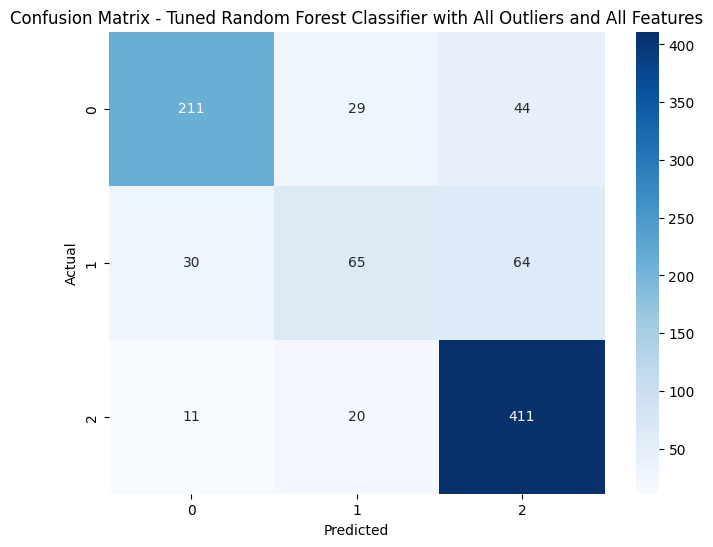

Confusion Matrix - Tuned Random Forest Classifier with All Outliers and Selected Features:


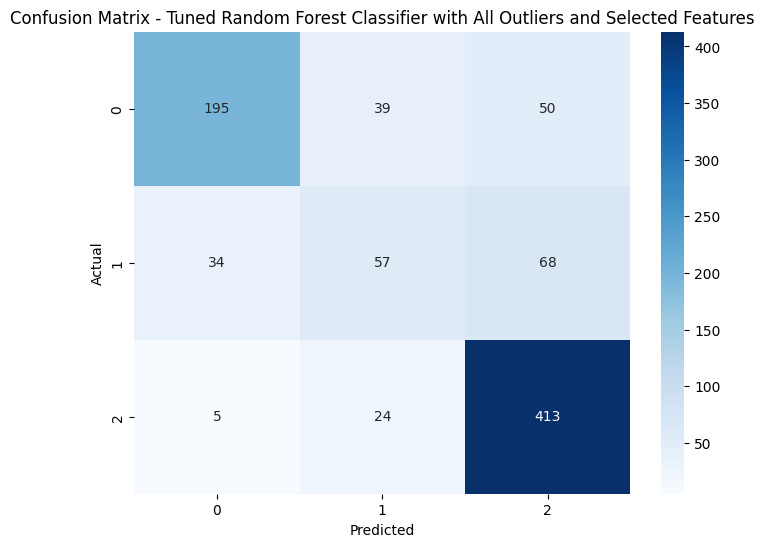

Confusion Matrix - Tuned Random Forest Classifier with No Outliers and All Features:


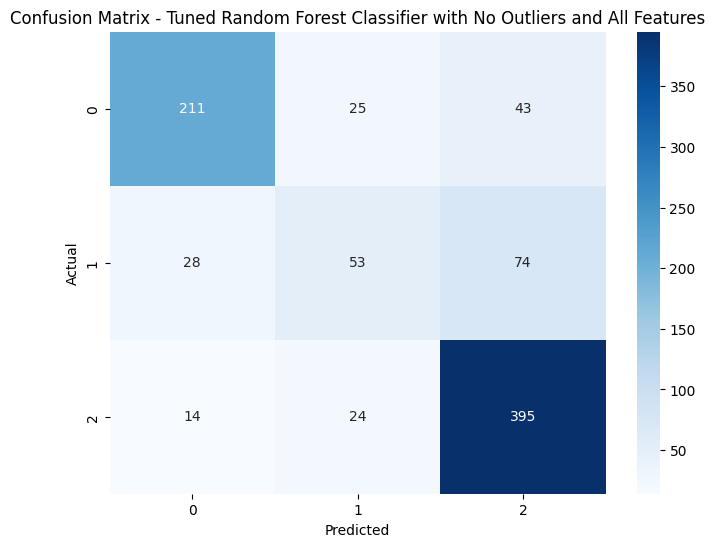

Confusion Matrix - Tuned Random Forest Classifier with No Outliers and Selected Features:


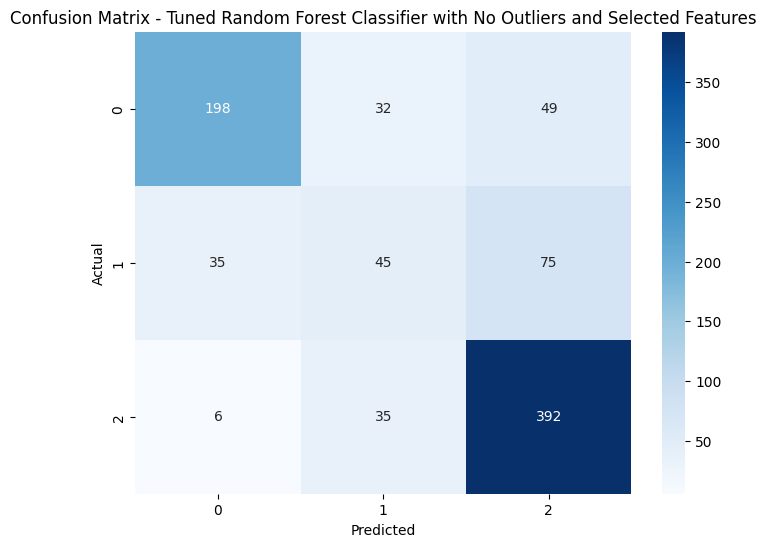

In [18]:
# Plot Confusion Matrix Chart after Hyperparameter Tuning with Coarse-to-Fine Search
print("Confusion Matrix - Tuned Random Forest Classifier with All Outliers and All Features after:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, rf_tuned_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned Random Forest Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, rf_tuned_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned Random Forest Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, rf_tuned_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned Random Forest Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, rf_tuned_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Accuracy Score after Hyperparameter Tuning with Coarse-to-Fine Search
print("Accuracy Score - Tuned Random Forest Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, rf_tuned_a_o_s_f_pred))
print("Accuracy Score - Tuned Random Forest Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, rf_tuned_n_o_s_f_pred))
print("Accuracy Score - Tuned Random Forest Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, rf_tuned_a_o_a_f_pred))
print("Accuracy Score - Tuned Random Forest Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, rf_tuned_n_o_a_f_pred))

Accuracy Score - Tuned Random Forest Classifier with All Outliers and Selected Features: 0.751412429378531
Accuracy Score - Tuned Random Forest Classifier with No Outliers and Selected Features: 0.7324106113033448
Accuracy Score - Tuned Random Forest Classifier with All Outliers and All Features: 0.7762711864406779
Accuracy Score - Tuned Random Forest Classifier with No Outliers and All Features: 0.7600922722029988


In [20]:
# Roc AUC Score after Hyperparameter Tuning with Coarse-to-Fine Search
print("ROC AUC Score - Tuned Random Forest Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, rf_tuned_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Tuned Random Forest Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, rf_tuned_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Tuned Random Forest Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, rf_tuned_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Tuned Random Forest Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, rf_tuned_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))

ROC AUC Score - Tuned Random Forest Classifier with All Outliers and Selected Features: 0.8688109570545048
ROC AUC Score - Tuned Random Forest Classifier with No Outliers and Selected Features: 0.8464230248898595
ROC AUC Score - Tuned Random Forest Classifier with All Outliers and All Features: 0.8876187218127226
ROC AUC Score - Tuned Random Forest Classifier with No Outliers and All Features: 0.8734075050730684


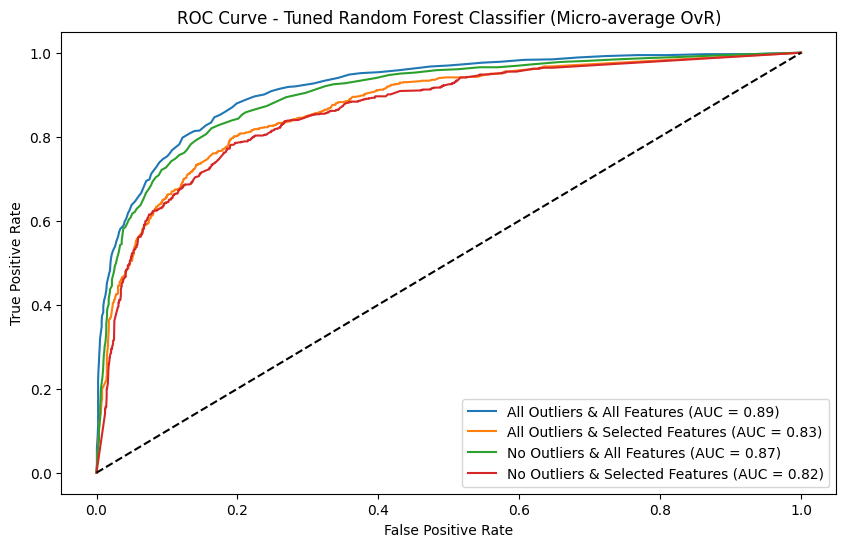

In [21]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, rf_a_o_a_f.predict_proba(X_test_a_o_a_f), rf_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, rf_a_o_s_f.predict_proba(X_test_a_o_s_f), rf_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, rf_n_o_a_f.predict_proba(X_test_n_o_a_f), rf_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, rf_n_o_s_f.predict_proba(X_test_n_o_s_f), rf_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

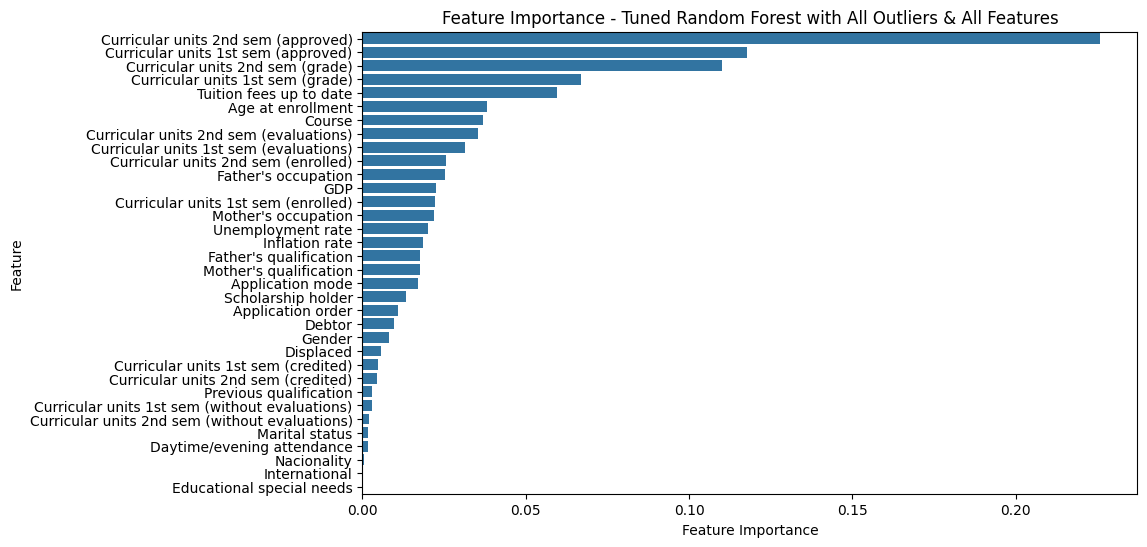

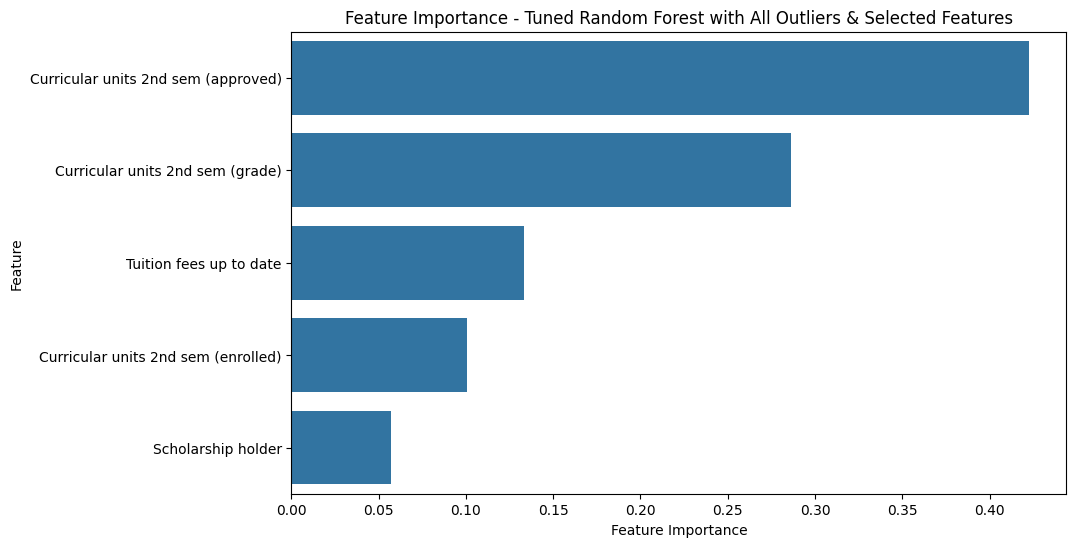

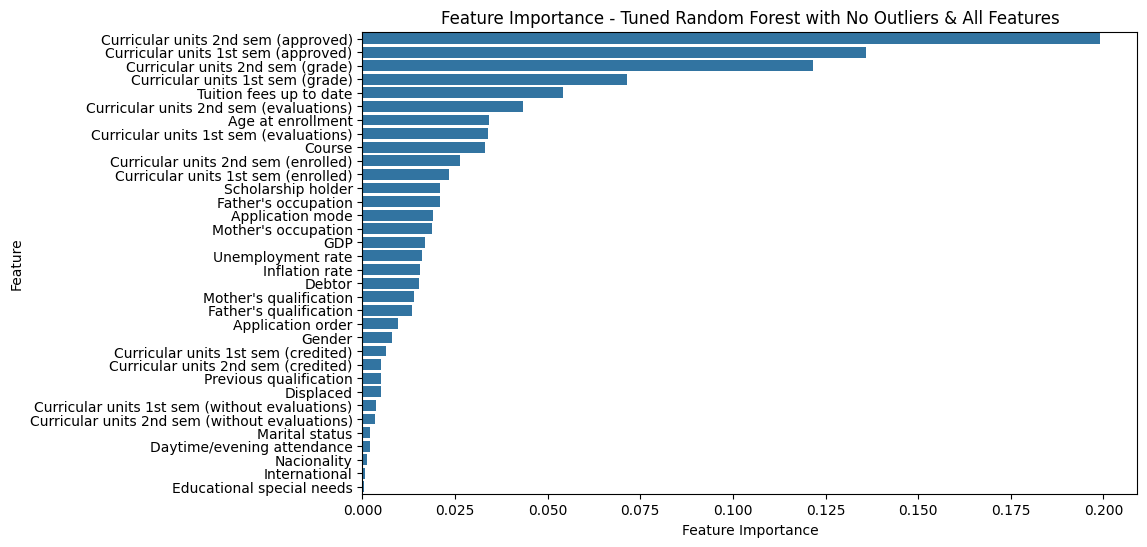

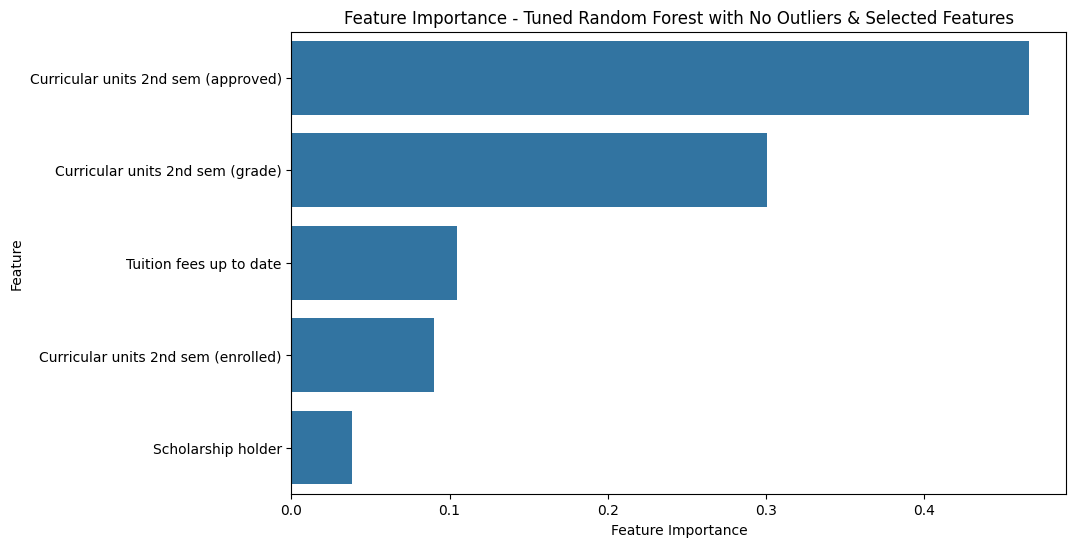

In [22]:
plot_feature_importance(rf_tuned_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - Tuned Random Forest with All Outliers & All Features")
plot_feature_importance(rf_tuned_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - Tuned Random Forest with All Outliers & Selected Features")
plot_feature_importance(rf_tuned_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - Tuned Random Forest with No Outliers & All Features")
plot_feature_importance(rf_tuned_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - Tuned Random Forest with No Outliers & Selected Features")

# **Random Forest Model Evaluation Report (Synced to Latest Rerun)**
**Project:** Classification with Random Forest  
**Tuning Method:** Coarse-to-Fine Search (RandomizedSearchCV -> GridSearchCV)  
**Validation:** Test split + 5-Fold CV (for tuned AOAF)

---

## 1. Tuned Model Results (Latest Rerun)

| Scenario | Accuracy | ROC-AUC |
|---|---:|---:|
| All Outliers + Selected Features | 0.7514 | 0.8688 |
| No Outliers + Selected Features | 0.7324 | 0.8464 |
| **All Outliers + All Features** | **0.7763** | **0.8876** |
| No Outliers + All Features | 0.7601 | 0.8734 |

### Cross Validation (Tuned AOAF)
- CV Mean (5-Fold): **0.7751**
- CV Std (5-Fold): **0.0088**

---

## 2. Key Findings
- Configuration terbaik di rerun ini adalah **All Outliers + All Features**.
- Variasi all-features unggul atas selected-features pada Random Forest.
- Outlier-retained data masih memberi sinyal yang berguna untuk model ini.
- Gap train-test masih menunjukkan potensi overfitting, namun konfigurasi terbaik tetap stabil secara CV.

---

## 3. Final Recommendation
Gunakan **Tuned Random Forest (All Outliers + All Features)** sebagai kandidat produksi dari notebook Random Forest ini.

# **Saving Final Model**

In [ ]:
# MODEL_DIR = "../models/random_forest_classifier_model"
# os.makedirs(MODEL_DIR, exist_ok=True)
# # Generate timestamp
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# # Save the best model (Tuned Random Forest (All Outliers + All Features)
# best_rf_model = rf_tuned_a_o_a_f
# model_filename = f"best_rf_classifier_model_{timestamp}.pkl"
# model_path = os.path.join(MODEL_DIR, model_filename)
# joblib.dump(best_rf_model, model_path)

# model_params = rf_tuned_a_o_a_f.get_params()

# feature_names = X_train_a_o_a_f.columns.tolist()
# feature_importances = rf_tuned_a_o_a_f.feature_importances_

# feature_importance_dict = [
#     {
#         'feature': name,
#         'importance': round(float(score), 6),
#         'percentage': f"{round(float(score) * 100, 2)}%"
#     }
#     for name, score in sorted(
#         zip(feature_names, feature_importances),
#         key=lambda x: x[1],
#         reverse=True  # urutkan dari yang paling penting
#     )
# ]

# # Create metadata for the saved model
# model_metadata = {
#     'model_name': 'Tuned Random Forest Classifier with All Outliers and All Features',
#     'description': 'This model is a Random Forest Classifier that has been tuned using GridSearchCV with a coarse-to-fine search strategy. It was trained on the dataset that includes all outliers and all features.',
#     'training_data': {
#         'dataset': 'data_cleaned_with_all_outliers_and_all_features.csv',
#         'features': X_train_a_o_a_f.columns.tolist(),
#         'target': 'Target',
#         'train_test_split': '80% train, 20% test',
#         'random_state': 42
#     },
#     'hyperparameters': {
#         'n_estimators': model_params['n_estimators'],
#         'max_depth': model_params['max_depth'],
#         'min_samples_split': model_params['min_samples_split'],
#         'min_samples_leaf': model_params['min_samples_leaf'],
#         'max_features': model_params['max_features'],
#         'max_samples': model_params['max_samples'],
#         'bootstrap': model_params['bootstrap']
#     },
#     'performance': {
#         'accuracy': accuracy_score(y_test_a_o_a_f, rf_tuned_a_o_a_f_pred),
#         'roc_auc': roc_auc_score(y_test_a_o_a_f, rf_tuned_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'),
#         'classification_report': classification_report(y_test_a_o_a_f, rf_tuned_a_o_a_f_pred, output_dict=True)
#     },
#     'feature_importance': feature_importance_dict,
#     'timestamp': timestamp,
#     'model_file': model_filename
# }
# # Save metadata
# metadata_filename = model_filename.replace('.pkl', '_metadata.json')
# metadata_path = os.path.join(MODEL_DIR, metadata_filename)

# with open(metadata_path, 'w') as f:
#     json.dump(model_metadata, f, indent=4)